<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solutions to Exercise Set 1 - 2-  SGD Parameters

Play with the parameters of the stochastic gradient descent algorithm.
 1. Execute the notebook with the high-level method from this morning's lecture as is (Kernel -> Restart & Run All).
 2. Jump to **Exercise** after the heading "Solution 2" and do as told there.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import time

/home/mario/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-03-07 14:16:23.647433: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-07 14:16:23.647921: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-07 14:16:23.650897: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-07 14:16:23.659013: E extern

In [2]:
# load the training data from the table file to a pandas data frame
df = pd.read_csv("../bikes-summerdays.tbl", sep=r'\s+')

# convert count data to floats as regression target
df['count'] = df['count'].astype(float) 

m, n_cols = df.shape # training set size and number of columns 
print("m = ", m, "\tn_cols = ", n_cols)

# compute average of hourly bike rental counts
meancount = np.mean(df['count'])

m =  1482 	n_cols =  2


## Create Data Matrix $X$ and response vector $y$

In [3]:
# extract response vector
y_train = np.array(df['count']) 

# extract feature columns
n = n_cols - 1 # number of features
temps = np.array(df.loc[:, df.columns != 'count']) # matrix of all other columns (here only one col)

# make data matrix X
X_train = np.ones((m, n+1)) # initialize with all ones
# overwrite all but the zero-th column with features
X_train[:,1:n+1] = temps / 10 - 2.5 # normalize temperatures so they are roughly in [-1,1] 

## Define Loss Function

In [4]:
# mean squared error loss function
def MSE(theta):
    """
        Mean squared error function for linear regression
        theta: numpy array of parameters, the first dimension must match the number of cols of X
               If theta is 2-dimensional, the output is 1-dim with one entry per col of theta.
    """
    if len(theta.shape) == 1: # theta is 1-dimensional
        theta = tf.reshape(theta, (-1, 1)) # make it a matrix with one column
    # now theta is a matrix in any case
    yhat = tf.linalg.matmul(X_train, theta) # vector of predicted rental counts
    d = (yhat - y_train.reshape((-1, 1)))**2 # square the residuals ('errors')
    E = tf.reduce_sum(d, axis=0) / m
    return E

In [5]:
# two tests of calls to error function
print("single point:", MSE(np.array([1., 2.])))
print("two points: ", MSE(np.array([[1., 3.], [2., 4.]])))

single point: tf.Tensor([126566.30681717], shape=(1,), dtype=float64)
two points:  tf.Tensor([126566.30681717 125266.24137933], shape=(2,), dtype=float64)


In [6]:
# this is for lecture purposes only and NEED NOT BE READ
def contourPlot():
    ''' Plot the error landscape'''
    # compute error for the grid of all combinations of theta0 and theta1 values
    theta0 = theta1 = np.arange(-3200., 3200., 100) # grid axis ranges
    xv, yv = np.meshgrid(theta0, theta1) # x and y values of all grid points
    Theta = np.array([xv, yv]).reshape(2, -1) # 2 rows, one col per grid point

    # compute error for all grid points
    z = MSE(Theta).numpy()
    z = z.reshape((theta0.size, -1)) # make this a matrix again as required by contour

    ## make contour plot
    _, axC = plt.subplots()
    # heights to draw contour lines for
    h = [50000, 200000] + list(range(500000, 6000001, 500000))
    contours = axC.contour(theta0, theta1, z, levels=h, colors='black')
    axC.clabel(contours, inline=True, fontsize=8, fmt='%i') # labels on lines
    plt.title("mean squared error " + r'$E(\theta)$');
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$');
    return axC


## Visualization of optimization progress

In [7]:
def plot_error(err, col):
    ''' Plot error over time'''
    plt.subplots()
    plt.plot(np.log(err), 'o-', color=col, linewidth=.2, markersize=3, mfc='none')
    plt.title("Log error by iteration of gradient descent")
    plt.xlabel('iteration '+r'$i$')
    plt.ylabel(r'$ln \;E(\theta^{(i)})$');

def plot_progress(Theta, err, col, ):
    '''Plot error and parameters over time'''
    plot_error(err, col)
    # enter parameter trajectory to above contour plot
    axC = contourPlot()
    plt.plot(Theta[0, 0], Theta[1, 0], 'o', color='green', mfc='none') # mark starting point with circle
    ymin, ymax = axC.get_ylim()
    xmin, xmax = axC.get_xlim()
    for i in range(1, Theta.shape[1]):
        if (np.abs(Theta[0, i] - Theta[0, i-1]) + np.abs(Theta[1, i] - Theta[1, i-1]) > 1e-6):
            # above condition avoids arrows with a length of 0 pixels
            plt.arrow(Theta[0, i-1], Theta[1, i-1], Theta[0, i] - Theta[0, i-1], Theta[1, i] - Theta[1, i-1],
                      color=col, width=3, head_length=20, head_width=50, overhang=.9, length_includes_head=True)

## Solution 2: high-level approach

**Exercise:**  
  1. Play with the *learning rate* $\alpha$. Find a *small* value and a *large* value so that **convergence is not reached**.
  2. Play with the *momentum* $\mu$. Find a *small* value and a *large* value so that **convergence is not reached**.
  3. Play with ```batch_size```. Find a *small* value so training is significantly **slower** and a *large* value so **convergence is not reached**.
  
When you vary one parameter, leave the other parameters as they were originally.

#### Classic Option 1: Use the **keyboard**
to edit the values in below cell, then **Run -> Run Selected Cell and Below**

In [8]:
# CHANGE THIS CODE HERE for Option 1. If you choose Option 2, leave these values as defaults (0.01, 0.8 and 32, respectively)
alpha = 0.01    # Solution: 0.001 and 1.7
mu = 0.8        # Solution: 0.0 and 0.98
batch_size = 32 # Solution: 2 and 200

#### Comfortable Option 2: Use the **mouse**
Execute the next two cells, use the sliders to adjust the values, then run the rest of the cells.  
*Tip:* **Create New View for Output** by right-clicking on the blue bar left of the graphs. Then drag the output window to a comfy place.

In [9]:
import ipywidgets as widgets
style = {'description_width': 'initial'}
layout = widgets.Layout(width = '100%')
alpha_slider = widgets.FloatLogSlider(value = alpha, min = -4, max = 1, step = 0.001,
    description = 'learning rate alpha', readout_format = '.4f',
    style = style, layout = layout)
mu_slider = widgets.FloatSlider(value = mu, min = 0, max = 1.0, step = 0.02,
    description = 'momentum mu', readout_format = '.2f',
    style = style, layout = layout)
batch_slider = widgets.IntSlider(value = batch_size, min = 1, max = m, step = 1,
                                 description = 'batch size:', style = style, layout = layout)

In [10]:
display(alpha_slider)
display(mu_slider)
display(batch_slider)

FloatLogSlider(value=0.01, description='learning rate alpha', layout=Layout(width='100%'), max=1.0, min=-4.0, …

FloatSlider(value=0.8, description='momentum mu', layout=Layout(width='100%'), max=1.0, step=0.02, style=Slide…

IntSlider(value=32, description='batch size:', layout=Layout(width='100%'), max=1482, min=1, style=SliderStyle…

In [11]:
alpha = alpha_slider.value
mu = mu_slider.value
batch_size = batch_slider.value

In [12]:
print ("Used values alpha =", alpha, ", mu =", mu, ", batch_size =", batch_size)

Used values alpha = 0.01 , mu = 0.8 , batch_size = 32


In [13]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
# A tf.data.Dataset has commonly used functions for random sampling, obtaining subsets, transformations
# iterating over large numbers of images on disk (using TFRecord).

dataset = dataset.shuffle(m).batch(batch_size) # random order and split into batches of size 32

# Get a predefined linear model with one single output variable (unit) and one weight per input.
theta_init = np.array([2000., 3000.])
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(2,))) # input layer with two features
model.add(tf.keras.layers.Dense(
    units = 1,
    use_bias = False, # bias equivalent to adding x_0 := 1
    kernel_initializer = tf.initializers.Constant(theta_init.reshape((2,1))), # default would be random initialization
    dtype = 'float64'))

optimizer = tf.keras.optimizers.SGD(learning_rate = alpha, momentum = mu)
# SGD: stochastic gradient descent

loss_object = tf.keras.losses.MeanSquaredError()
# This common and preimplemented loss implements the MSE function defined in equation (1).

#we compile the model and tell the framework which loss function to use
model.compile(optimizer = optimizer, loss = loss_object)

class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        self.theta = []
    
    def on_epoch_end(self, batch, logs=None):
        self.theta.append(tf.squeeze(model.get_weights()[0]).numpy())
        
callback = CustomCallback()


In [14]:

start = time.time()
# Fit the model for 5 epochs (i.e. each datapoint is seen 5 times).
# Calling this is analogous to our previously implemented low-level training loop.
# It's just much simpler and in most cases what you want to use to train a model.
history = model.fit(dataset, epochs=10, callbacks=[callback])
end = time.time()
print("Training took", end - start, "seconds.")

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - loss: 2417599.2500 
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 154270.3438
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - loss: 36599.0820
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 31049.8164
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - loss: 25938.4316
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 27287.2070
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 26493.4414
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - loss: 29078.4473
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 27172.4004
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - loss: 28566.4785
Training took 0.4717438220977783 seconds.


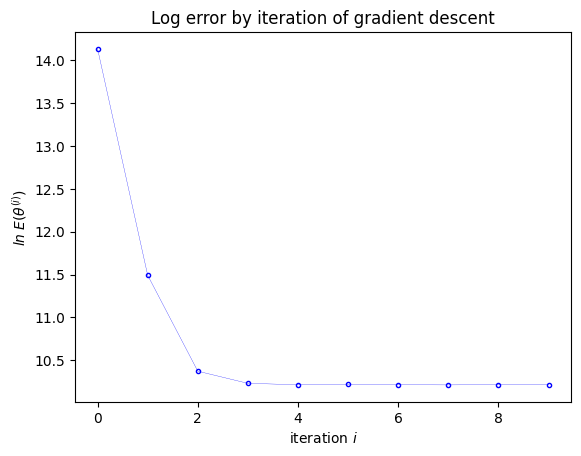

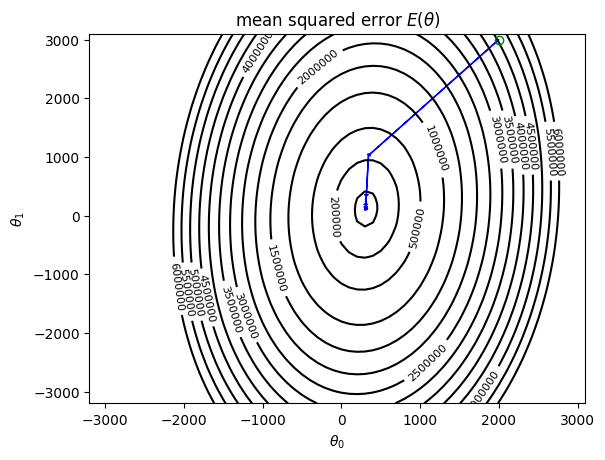

In [16]:
plot_progress(np.stack([theta_init] + callback.theta, -1), history.history["loss"], col='blue');

**Remarks:**
  - In above plot of training error, the errors were measured only on a batch and are thus estimates of the training error only.
  - When using stochastic gradient descent, typically the parameter trajectory eventually random walks near a local optimum and their latest values may result in a larger loss than some parameter value previously attained.

In [17]:
# final loss and prediction computed on all training data
pred = model(X_train)
pred = tf.reshape(pred, [m])
E = loss_object(y_train, pred)
print("final error = ", E.numpy())
print("theta:\n", model.trainable_variables[0].numpy())

final error =  27228.596
theta:
 [[317.58766443]
 [117.23951877]]
